# PYTHON ANALYSIS : the effect of a prevention program on wrist extension and forearm supination in leather workers.
Student : DUPLAIX JAHINNA


This notebook contains the Python part of the movement analysis project.
It is used to:

PART 1 : Data cleaning and preparation
- I. Inspect the raw dataset
- II. Clean the data

PART 2 : 
- I. Create derived variables
- II. Inspect extreme change scores
- III. Produce basic exploratory outputs
- IV. Export dataset file

First, we need to import the necessary libraries.

In [1]:
# This command imports the Python libraries needed for the project.
# - pandas: used to read and manipulate tables
# - openpyxl: used to read Excel files
# - matplotlib: used to create simple figures in Python
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# PART 1 : DATA CLEANING AND PREPARATION

## I. Inspect the raw dataset

We first load the raw dataset and inspect its general structure.
This first step helps us understand:
- how many rows and columns are present,
- which variables are available,
- how the variables are stored,
- whether there are missing values or duplicate rows.

At this stage, no cleaning is performed yet.
We only observe the dataset in its original form.

In [2]:

# This line stores the path of the Excel file, the file is inside the "data" folder of the project.
file_path = "data/TMinstitute_prevention_base_2025.xlsx"

# This line reads the Excel file and lists the sheet names, it is useful to check that the expected sheet exists.
excel_file = pd.ExcelFile(file_path)
print("Sheets:", excel_file.sheet_names)

# This line reads the sheet named "range_of_motion", the raw dataset is stored in df_raw.
df_raw = pd.read_excel(file_path, sheet_name="range_of_motion")

# This line creates a copy of the raw dataset, we work on df so that the original imported table remains unchanged.
df = df_raw.copy()

# This line prints the number of rows and columns.
print("Shape:", df.shape)

# This line prints the column names.
print("\nColumns:")
print(df.columns.tolist())

# This line prints the data type of each column, it helps us see which variables are text and which are numeric.
print("\nDtypes:")
print(df.dtypes)

# This line counts the values of the timepoint column, it helps detect inconsistent labels such as T0, T 0, t0, etc.
print("\nTimepoint values before cleaning:")
print(df["timepoint"].value_counts(dropna=False))

# This line counts missing values in each column.
print("\nMissing values by column:")
print(df.isna().sum())

# This line counts exact duplicate rows.
print("\nExact duplicate rows:", df.duplicated().sum())

# This line displays the first rows of the dataset.
print("\nFirst rows:")
print(df.head())

Sheets: ['range_of_motion']
Shape: (950, 4)

Columns:
['participant_id', 'timepoint', 'wrist_extension_deg', 'forearm_supination_deg']

Dtypes:
participant_id                str
timepoint                     str
wrist_extension_deg       float64
forearm_supination_deg     object
dtype: object

Timepoint values before cleaning:
timepoint
T0     475
T1     470
T0       1
t0       1
T 1      1
t1       1
T 0      1
Name: count, dtype: int64

Missing values by column:
participant_id            0
timepoint                 0
wrist_extension_deg       4
forearm_supination_deg    4
dtype: int64

Exact duplicate rows: 4

First rows:
  participant_id timepoint  wrist_extension_deg forearm_supination_deg
0           M001        T0                 51.9                   82.1
1           M001        T1                 55.3                   85.4
2           M002        T0                 43.2                   70.5
3           M002        T1                 44.7                   74.2
4           M

Our database contains a single excel sheet "range_of_motion" with 950 rows and 4 columns. So we have 4 variables:

- participant_id
- timepoint
- wrist_extension_deg
- forearm_supination_deg

We can see that : 
- the timepoint labels are not fully harmonized
- there are duplicates because we don't have the same number of participants in TO and T1
- forearm_supination_deg is not yet stored as a numeric variable
- there are 8 missing values

The next step is to clean the dataset.

## II. Clean the dataset

The cleaning process is organized in several steps.

First, we standardize the text variables.
Then, we convert the movement variables to numeric format.
After that, we remove exact duplicate rows.
Finally, we check whether each participant has a valid longitudinal structure before reshaping the dataset.

### II.1. Standardize participant labels, timepoint labels, and movement variables

Before performing any longitudinal analysis, the variables must be harmonized.

This step has three objectives:
1. clean the participant identifiers,
2. harmonize the timepoint labels,
3. convert the movement variables into numeric values.

This is necessary because the same information can be written in slightly different ways in the raw file.
For example:
- a participant ID may contain unnecessary spaces,
- a timepoint may appear as "T0", "t0", or "T 0",
- a movement value may contain symbols such as "°".

These inconsistencies must be corrected before the dataset can be analyzed properly.

In [3]:
# This line converts participant_id to pandas "string" format.
# We do not use astype(str), because that could transform missing values into the text "nan".
df["participant_id"] = df["participant_id"].astype("string")

# This line removes unnecessary spaces before and after each participant ID (e.g., " M001 " becomes "M001").
df["participant_id"] = df["participant_id"].str.strip()

# This line converts timepoint to pandas "string" format.
df["timepoint"] = df["timepoint"].astype("string")

# This line removes spaces before and after each timepoint label.
df["timepoint"] = df["timepoint"].str.strip()

# This line changes all letters to uppercase (e.g., "t0" becomes "T0").
df["timepoint"] = df["timepoint"].str.upper()

# This line removes spaces inside the label (e.g., "T 0" becomes "T0").
df["timepoint"] = df["timepoint"].str.replace(r"\s+", "", regex=True)

# This loop applies the same cleaning to the two movement variables.
for col in ["wrist_extension_deg", "forearm_supination_deg"]:
    
    # First, the column is converted to pandas "string" format.
    df[col] = df[col].astype("string")
    
    # This line removes the degree symbol if it exists (e.g., "80°" becomes "80").
    df[col] = df[col].str.replace("°", "", regex=False)
    
    # This line removes unnecessary spaces.
    df[col] = df[col].str.strip()
    
    # This line converts the cleaned text to numeric format, if a value cannot be converted, it becomes missing (NaN).
    df[col] = pd.to_numeric(df[col], errors="coerce")


# This line displays the cleaned timepoint values.
print("Timepoint values after cleaning:")
print(df["timepoint"].value_counts(dropna=False))

# This line displays the data types after cleaning.
print("\nDtypes after cleaning:")
print(df.dtypes)

Timepoint values after cleaning:
timepoint
T0    478
T1    472
Name: count, dtype: Int64

Dtypes after cleaning:
participant_id             string
timepoint                  string
wrist_extension_deg       Float64
forearm_supination_deg    Float64
dtype: object


### II.2. Detect and handle implausible raw movement values

Once the movement variables have been converted to numeric format, implausible raw values ​​can be detected automatically.

The objective is to identify raw values ​​that are not plausible for joint range-of-motion measurements and that may reflect a data-entry error.

Flagged values ​​are first reviewed.
If the true value can be verified from the original source, it can be corrected.
If the true value cannot be verified, it is safer to recode it as missing so that the participant is excluded later from the complete-case analysis.

In [4]:
# Define a broad plausibility range for raw range-of-motion values in degrees.
# This rule is used only to detect obvious data-entry errors.
min_rom_deg = 0
max_rom_deg = 180

movement_cols = ["wrist_extension_deg", "forearm_supination_deg"]

# Identify rows with at least one implausible raw movement value.
implausible_mask = pd.Series(False, index=df.index)

for col in movement_cols:
    implausible_mask = implausible_mask | (
        df[col].notna() & ((df[col] < min_rom_deg) | (df[col] > max_rom_deg))
    )

# Display flagged rows before handling them.
implausible_rows = df.loc[
    implausible_mask,
    ["participant_id", "timepoint"] + movement_cols
].sort_values(["participant_id", "timepoint"])

print("Rows with implausible raw movement values:")
print(implausible_rows)

# Recode implausible raw values as missing.
for col in movement_cols:
    df.loc[
        df[col].notna() & ((df[col] < min_rom_deg) | (df[col] > max_rom_deg)),
        col
    ] = float("nan")

# Display the flagged rows after recoding.
print("\nRows after recoding implausible values as missing:")
print(
    df.loc[
        implausible_mask,
        ["participant_id", "timepoint"] + movement_cols
    ].sort_values(["participant_id", "timepoint"])
)

Rows with implausible raw movement values:
    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
318           M160        T0                462.0                    75.7

Rows after recoding implausible values as missing:
    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
318           M160        T0                 <NA>                    75.7


### II.3. Remove exact duplicate rows and inspect missing values

We now remove exact duplicate rows.

An exact duplicate row means that all values are identical to another row.
Such duplicates do not provide new information and can artificially inflate the dataset.

After removing them, we inspect missing values.
At this stage, rows with missing movement values are not deleted yet.
They are kept temporarily because completeness will be evaluated more appropriately after reshaping the dataset into wide format.

In [5]:
# This line stores the number of rows before duplicate removal.
n_rows_before = len(df)

# This line counts how many rows are exact duplicates.
n_exact_duplicates = df.duplicated().sum()

# This line removes exact duplicate rows.
df = df.drop_duplicates().copy()

# This line stores the number of rows after duplicate removal.
n_rows_after = len(df)

# These lines print the main results of duplicate removal.
print("Rows before duplicate removal:", n_rows_before)
print("Exact duplicate rows removed:", n_exact_duplicates)
print("Rows after duplicate removal:", n_rows_after)

# This line counts missing values in each column after duplicate removal.
print("\nMissing values by column:")
print(df.isna().sum())

Rows before duplicate removal: 950
Exact duplicate rows removed: 4
Rows after duplicate removal: 946

Missing values by column:
participant_id            0
timepoint                 0
wrist_extension_deg       5
forearm_supination_deg    4
dtype: int64


### II.4. Inspect rows with missing movement values

We now display the rows in which at least one movement variable is missing.

This step is useful for understanding where incompleteness occurs.
These rows are not removed yet.
They will only be excluded later if they prevent the construction of a complete paired T0-T1 dataset.

In [6]:
# This line selects rows with at least one missing value, in wrist extension or forearm supination.
missing_rows = df[
    df[["wrist_extension_deg", "forearm_supination_deg"]]
    .isna()
    .any(axis=1)].copy()

# This line sorts these rows by participant and timepoint, to make them easier to read.
missing_rows = missing_rows.sort_values(["participant_id", "timepoint"])

# This line displays the incomplete rows.
print(missing_rows)

    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
165           M083        T1                 <NA>                    70.6
307           M154        T1                 63.4                    <NA>
315           M158        T1                 <NA>                    74.6
318           M160        T0                 <NA>                    75.7
394           M198        T0                 40.8                    <NA>
452           M227        T0                 <NA>                    76.2
602           M302        T0                 <NA>                    67.4
694           M348        T0                 66.6                    <NA>
894           M448        T0                 46.9                    <NA>


### II.5. Check the longitudinal structure of the dataset

Before reshaping the dataset, we must verify that the longitudinal structure is valid.

For a participant to be valid in this study, two conditions must be met:
1. the participant must have exactly two rows,
2. the participant must have exactly two distinct timepoints.

This is necessary because the final analyses compare repeated measures between T0 and T1.
A participant with an invalid structure cannot contribute correctly to this comparison.

In [7]:
# This line counts the number of rows for each participant.
rows_per_participant = df.groupby("participant_id").size()

# This line shows the distribution of row counts, it tells us how many participants have 1 row, 2 rows, 3 rows, etc.
print("Distribution of rows per participant:")
print(rows_per_participant.value_counts().sort_index())


# This line selects participants whose number of rows is not equal to 2.
participants_wrong_nrows = rows_per_participant[rows_per_participant != 2]

# This line displays these participants.
print("\nParticipants with a number of rows different from 2:")
print(participants_wrong_nrows)


# This line counts the number of distinct timepoints for each participant.
# We use nunique() because we want the number of different labels, not the number of rows.
timepoints_per_participant = df.groupby("participant_id")["timepoint"].nunique(dropna=True)

# This line shows the distribution of the number of distinct timepoints.
print("\nDistribution of distinct timepoints per participant:")
print(timepoints_per_participant.value_counts().sort_index())


# This line selects participants whose number of distinct timepoints is not equal to 2.
participants_wrong_timepoints = timepoints_per_participant[timepoints_per_participant != 2]

# This line displays these participants.
print("\nParticipants with a number of distinct timepoints different from 2:")
print(participants_wrong_timepoints)


# This line counts duplicated participant-timepoint pairs, it helps detect cases where the same participant appears twice at the same timepoint.
duplicate_pairs = df.duplicated(subset=["participant_id", "timepoint"]).sum()

print("\nDuplicated participant-timepoint pairs:", duplicate_pairs)


# This line combines the two lists of invalid participants:
# - those with the wrong number of rows
# - those with the wrong number of distinct timepoints
invalid_participants = sorted(
    set(participants_wrong_nrows.index).union(set(participants_wrong_timepoints.index))
)

# This line displays the IDs of invalid participants.
print("\nInvalid participants:")
print(invalid_participants)


# This line displays the full rows of invalid participants.
# It helps understand why their structure is invalid.
invalid_rows = df[df["participant_id"].isin(invalid_participants)].sort_values(
    ["participant_id", "timepoint"])

print("\nRows of invalid participants:")
print(invalid_rows)

Distribution of rows per participant:
2    473
Name: count, dtype: int64

Participants with a number of rows different from 2:
Series([], dtype: int64)

Distribution of distinct timepoints per participant:
timepoint
1      3
2    470
Name: count, dtype: int64

Participants with a number of distinct timepoints different from 2:
participant_id
M148    1
M212    1
M285    1
Name: timepoint, dtype: int64

Duplicated participant-timepoint pairs: 3

Invalid participants:
['M148', 'M212', 'M285']

Rows of invalid participants:
    participant_id timepoint  wrist_extension_deg  forearm_supination_deg
294           M148        T0                 50.3                    56.9
295           M148        T0                 50.4                    55.8
422           M212        T1                 53.1                    64.5
423           M212        T1                 56.0                    65.6
568           M285        T0                 52.9                    72.5
569           M285        T0  

The invalid participants identified above are excluded from the dataset.

This exclusion is necessary because a valid longitudinal comparison requires one participant, one baseline measure, and one follow-up measure.
Participants with an invalid structure would make the paired analysis unreliable.

In [8]:
# This line keeps only participants with a valid longitudinal structure.
df_valid = df[~df["participant_id"].isin(invalid_participants)].copy()

# This line prints the number of rows remaining.
print("Rows in the valid long-format dataset:", len(df_valid))

# This line prints the number of unique participants remaining.
print("Participants in the valid long-format dataset:", df_valid["participant_id"].nunique())

Rows in the valid long-format dataset: 940
Participants in the valid long-format dataset: 470


### II.6. Reshape the valid dataset into wide format

The cleaned long-format dataset is now reshaped into wide format.

- In long format, each participant has one row per timepoint.
- In wide format, each participant has a single row, with separate columns for T0 and T1.

This format is more appropriate for paired analyses because each participant’s repeated measures are stored on the same row.

In [9]:
# This line reshapes the valid long-format dataset into wide format.
# - participant_id becomes the row identifier.
# - timepoint becomes the column level.
# - the movement variables become the values.
df_wide = df_valid.pivot(
    index="participant_id",
    columns="timepoint",
    values=["wrist_extension_deg", "forearm_supination_deg"]
)

# After pivoting, the columns have a hierarchical structure.
# This line flattens the column names into a simple format.
# For example, ("wrist_extension_deg", "T0") becomes "wrist_extension_deg_T0".
df_wide.columns = [f"{var}_{tp}" for var, tp in df_wide.columns]

# This line brings participant_id back as a normal column.
df_wide = df_wide.reset_index()

# These lines force the movement columns in the wide dataset to numeric format.
# This step is necessary because after pivoting, pandas may keep these columns as object.
wide_numeric_cols = [
    "wrist_extension_deg_T0",
    "wrist_extension_deg_T1",
    "forearm_supination_deg_T0",
    "forearm_supination_deg_T1"
]

for col in wide_numeric_cols:
    df_wide[col] = pd.to_numeric(df_wide[col], errors="coerce")

# These lines display the shape, the first rows, and the data types of the wide dataset.
print("Shape of wide dataset:", df_wide.shape)
print(df_wide.head())
print(df_wide.dtypes)

Shape of wide dataset: (470, 5)
  participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
0           M001                    51.9                    55.3   
1           M002                    43.2                    44.7   
2           M003                    47.2                    47.8   
3           M004                    46.0                    45.1   
4           M005                    56.4                    59.1   

   forearm_supination_deg_T0  forearm_supination_deg_T1  
0                       82.1                       85.4  
1                       70.5                       74.2  
2                       62.6                       64.3  
3                       72.9                       74.4  
4                       65.2                       69.1  
participant_id                string
wrist_extension_deg_T0       float64
wrist_extension_deg_T1       float64
forearm_supination_deg_T0    float64
forearm_supination_deg_T1    float64
dtype: object


### II.7. Inspect missing values in the wide dataset

Once the dataset is in wide format, we can check completeness at the participant level.

At this stage, each participant should ideally have:
- wrist extension at T0,
- wrist extension at T1,
- forearm supination at T0,
- forearm supination at T1.

Participants with missing values in any of these four measurements cannot be included in the final paired analysis.

In [10]:
# This line counts missing values in each column of the wide dataset.
print(df_wide.isna().sum())


participant_id               0
wrist_extension_deg_T0       3
wrist_extension_deg_T1       2
forearm_supination_deg_T0    3
forearm_supination_deg_T1    1
dtype: int64


We have 8 missing values in the 2 mouvement variables.

### II.8. Create the final analysis dataset

The final analysis dataset includes only participants with complete values for all four movement variables:
- `wrist extension at T0`,
- `wrist extension at T1`,
- `forearm supination at T0`,
- `forearm supination at T1`.

This step produces the complete-case dataset used for the final analyses.

In [11]:
# This list contains the four movement variables required for analysis.
required_columns = [
    "wrist_extension_deg_T0",
    "wrist_extension_deg_T1",
    "forearm_supination_deg_T0",
    "forearm_supination_deg_T1"
]

# This line removes participants with at least one missing value
# in the four required movement columns.
analysis_df = df_wide.dropna(subset=required_columns).copy()

# This line calculates how many participants were excluded at this step.
n_removed_missing = len(df_wide) - len(analysis_df)

# These lines print the result of the complete-case selection.
print("Rows in wide dataset:", len(df_wide))
print("Rows in final analysis dataset:", len(analysis_df))
print("Participants excluded because of missing movement data:", n_removed_missing)

Rows in wide dataset: 470
Rows in final analysis dataset: 461
Participants excluded because of missing movement data: 9


### II.9. Cleaning summary

We now summarize the main steps of the cleaning and preparation process.

This summary allows us to keep a clear trace of:
- the initial number of participants,
- the number of participants excluded because of an invalid longitudinal structure,
- the number excluded because of missing movement data,
- the final number retained for analysis.

In [12]:
# This line counts the number of unique participants in the raw dataset.
# We clean participant_id first to avoid counting the same participant twice because of extra spaces.
n_participants_initial = (
    df_raw["participant_id"]
    .astype("string")
    .str.strip()
    .nunique(dropna=True)
)

# This line counts the number of participants after duplicate removal.
n_participants_after_duplicates = df["participant_id"].nunique(dropna=True)

# This line counts how many participants had an invalid longitudinal structure.
n_invalid_participants = len(invalid_participants)

# This line counts the number of valid participants after structural exclusion.
n_participants_valid = df_valid["participant_id"].nunique(dropna=True)

# This line counts how many participants were excluded because of missing movement data.
n_excluded_missing = len(df_wide) - len(analysis_df)

# This line counts the final number of participants retained in the analysis dataset.
n_final_analysis = analysis_df["participant_id"].nunique(dropna=True)

# These lines print the full cleaning summary.
print("Cleaning summary")
print("----------------")
print("Initial number of participants:", n_participants_initial)
print("Participants after duplicate removal:", n_participants_after_duplicates)
print("Participants excluded because of invalid longitudinal structure:", n_invalid_participants)
print("Participants remaining after structural check:", n_participants_valid)
print("Participants excluded because of missing movement data:", n_excluded_missing)
print("Final number of participants in analysis dataset:", n_final_analysis)
print("______________________________________________________")
print("Final shape of dataset : analaysis_df")
print("-----------------")
print(analysis_df.shape)
print(analysis_df.head())

Cleaning summary
----------------
Initial number of participants: 473
Participants after duplicate removal: 473
Participants excluded because of invalid longitudinal structure: 3
Participants remaining after structural check: 470
Participants excluded because of missing movement data: 9
Final number of participants in analysis dataset: 461
______________________________________________________
Final shape of dataset : analaysis_df
-----------------
(461, 5)
  participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
0           M001                    51.9                    55.3   
1           M002                    43.2                    44.7   
2           M003                    47.2                    47.8   
3           M004                    46.0                    45.1   
4           M005                    56.4                    59.1   

   forearm_supination_deg_T0  forearm_supination_deg_T1  
0                       82.1                       85.4  
1            

The final analysis dataset contains one row per participant and only complete paired measurements at T0 and T1 for both movement variables.
This dataset is now ready for the statistical analyses.

# PART 2 : ANALYSIS DATASET PREPARATION AND EXPLORATORY VISUALIZATION

In this part, we create the change variables, export the final analysis dataset, and produce histograms to explore the distribution of the variables before the statistical analyses.

## I. Create derived change variables

The cleaned and complete analysis dataset is now used to compute change scores for the two range-of-motion outcomes.

Two variables are created:

- `delta_wrist_extension_deg`: wrist extension at T1 `-` wrist extension at T0
- `delta_forearm_supination_deg`: forearm supination at T1 `-` forearm supination at T0

These variables represent the individual changes in range of motion over time.
They will be used later for descriptive statistics, data visualization, and statistical analyses in RStudio.

In [13]:
# Create the change variable for wrist extension
analysis_df["delta_wrist_extension_deg"] = (
    analysis_df["wrist_extension_deg_T1"] - analysis_df["wrist_extension_deg_T0"]
)

# Create the change variable for forearm supination
analysis_df["delta_forearm_supination_deg"] = (
    analysis_df["forearm_supination_deg_T1"] - analysis_df["forearm_supination_deg_T0"]
)

# Display the first rows of the updated analysis dataset
print(analysis_df.head())

# Display simple descriptive statistics for the change variables
print(
    analysis_df[
        ["delta_wrist_extension_deg", "delta_forearm_supination_deg"]
    ].describe())



  participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
0           M001                    51.9                    55.3   
1           M002                    43.2                    44.7   
2           M003                    47.2                    47.8   
3           M004                    46.0                    45.1   
4           M005                    56.4                    59.1   

   forearm_supination_deg_T0  forearm_supination_deg_T1  \
0                       82.1                       85.4   
1                       70.5                       74.2   
2                       62.6                       64.3   
3                       72.9                       74.4   
4                       65.2                       69.1   

   delta_wrist_extension_deg  delta_forearm_supination_deg  
0                        3.4                           3.3  
1                        1.5                           3.7  
2                        0.6                         

## II. Inspect extreme change scores

Once the change scores have been computed, the most extreme values are reviewed.
This step is used to identify potentially unusual observations and to distinguish true extreme changes from possible data-entry errors.

Extreme change scores are not removed automatically.
They are only corrected or excluded if the underlying raw values are shown to be erroneous in the source data.
Otherwise, they are retained in the analysis dataset.

In [14]:
# Inspect the most negative and most positive wrist extension changes
print("Most negative wrist extension changes:")
print(
    analysis_df[
        [
            "participant_id",
            "wrist_extension_deg_T0",
            "wrist_extension_deg_T1",
            "delta_wrist_extension_deg"
        ]
    ].sort_values("delta_wrist_extension_deg").head(10)
)

print("\nMost positive wrist extension changes:")
print(
    analysis_df[
        [
            "participant_id",
            "wrist_extension_deg_T0",
            "wrist_extension_deg_T1",
            "delta_wrist_extension_deg"
        ]
    ].sort_values("delta_wrist_extension_deg", ascending=False).head(10)
)

print("\nMost negative forearm supination changes:")
print(
    analysis_df[
        [
            "participant_id",
            "forearm_supination_deg_T0",
            "forearm_supination_deg_T1",
            "delta_forearm_supination_deg"
        ]
    ].sort_values("delta_forearm_supination_deg").head(10)
)

print("\nMost positive forearm supination changes:")
print(
    analysis_df[
        [
            "participant_id",
            "forearm_supination_deg_T0",
            "forearm_supination_deg_T1",
            "delta_forearm_supination_deg"
        ]
    ].sort_values("delta_forearm_supination_deg", ascending=False).head(10)
)


Most negative wrist extension changes:
    participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
160           M162                    79.8                    42.3   
183           M185                    57.9                    56.7   
417           M421                    54.7                    53.6   
55            M056                    53.9                    52.8   
178           M180                    53.8                    52.7   
198           M200                    50.3                    49.3   
362           M366                    59.9                    58.9   
123           M124                    48.8                    47.8   
279           M282                    50.8                    49.8   
78            M079                    56.2                    55.3   

     delta_wrist_extension_deg  
160                      -37.5  
183                       -1.2  
417                       -1.1  
55                        -1.1  
178                      

Several extreme values ​​are present, we will isolate them to verify them.

In [15]:
# Review selected extreme observations
extreme_ids = ["M162", "M196", "M275", "M300"]

extreme_observations = analysis_df.loc[
    analysis_df["participant_id"].isin(extreme_ids),
    [
        "participant_id",
        "wrist_extension_deg_T0",
        "wrist_extension_deg_T1",
        "delta_wrist_extension_deg",
        "forearm_supination_deg_T0",
        "forearm_supination_deg_T1",
        "delta_forearm_supination_deg"
    ]
].sort_values("participant_id")

print("Selected extreme observations reviewed:")
print(extreme_observations)

Selected extreme observations reviewed:
    participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
160           M162                    79.8                    42.3   
194           M196                    49.8                    81.2   
272           M275                    45.7                    45.7   
296           M300                    51.2                    52.5   

     delta_wrist_extension_deg  forearm_supination_deg_T0  \
160                      -37.5                       43.4   
194                       31.4                       74.9   
272                        0.0                       69.0   
296                        1.3                       62.3   

     forearm_supination_deg_T1  delta_forearm_supination_deg  
160                       46.5                           3.1  
194                       77.2                           2.3  
272                       98.9                          29.9  
296                       97.8                     

Several extreme change scores were reviewed individually after computation of the delta variables.

This review showed that the most extreme observations did not all concern the same outcome:
- `M162` showed the most extreme negative change in wrist extension (`-37.5` degrees),
- `M196` showed a large positive change in wrist extension (`+31.4` degrees),
- `M275` and `M300` showed large positive changes in forearm supination (`+29.9` and `+35.5` degrees).

At this stage, these observations are only flagged and documented.
They are not removed automatically, because an extreme change score does not necessarily indicate a data-entry error.
Only raw values that are impossible or clearly erroneous in the source data are corrected or excluded during the cleaning phase.

In [16]:
# Quick verification of the delta calculation on a few rows
print(
    analysis_df[
        [
            "participant_id",
            "wrist_extension_deg_T0",
            "wrist_extension_deg_T1",
            "delta_wrist_extension_deg",
            "forearm_supination_deg_T0",
            "forearm_supination_deg_T1",
            "delta_forearm_supination_deg"
        ]
    ].head(10))

  participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
0           M001                    51.9                    55.3   
1           M002                    43.2                    44.7   
2           M003                    47.2                    47.8   
3           M004                    46.0                    45.1   
4           M005                    56.4                    59.1   
5           M006                    46.9                    49.5   
6           M007                    53.7                    56.6   
7           M008                    65.1                    65.1   
8           M009                    59.5                    62.4   
9           M010                    46.7                    49.5   

   delta_wrist_extension_deg  forearm_supination_deg_T0  \
0                        3.4                       82.1   
1                        1.5                       70.5   
2                        0.6                       62.6   
3              

Overall, the delta variables were successfully computed from the final cleaned dataset and provide a direct measure of individual change between T0 and T1 for wrist extension and forearm supination.

At this stage, the delta variables are used for descriptive and exploratory purposes only.
Their distribution has been reviewed, and extreme observations have been identified and documented.

The dataset is now ready to be used for exploratory visualizations.

## III. Produce descriptive and exploratory outputs

### III.1. Create a descriptive summary table
Before exporting the final dataset, a descriptive summary table is produced for the main variables and the derived change scores.

This table provides a numerical overview of the dataset, including the number of observations, measures of central tendency, dispersion, and range.

At this stage, the table is used for descriptive purposes only.

`Table 1. Descriptive summary of wrist extension, forearm supination, and derived change scores in the final analysis dataset.`

In [17]:
# List of variables to summarize
variables_to_summarize = [
    "wrist_extension_deg_T0",
    "wrist_extension_deg_T1",
    "forearm_supination_deg_T0",
    "forearm_supination_deg_T1",
    "delta_wrist_extension_deg",
    "delta_forearm_supination_deg"
]
# More readable labels for the final table
variable_labels = {
    "wrist_extension_deg_T0": "Wrist extension at T0 (deg)",
    "wrist_extension_deg_T1": "Wrist extension at T1 (deg)",
    "forearm_supination_deg_T0": "Forearm supination at T0 (deg)",
    "forearm_supination_deg_T1": "Forearm supination at T1 (deg)",
    "delta_wrist_extension_deg": "Change in wrist extension (T1 - T0, deg)",
    "delta_forearm_supination_deg": "Change in forearm supination (T1 - T0, deg)"}

# Create a descriptive summary table
descriptive_table = pd.DataFrame({
    "Variable": variables_to_summarize,
    "N": [analysis_df[col].count() for col in variables_to_summarize],
    "Mean": [analysis_df[col].mean() for col in variables_to_summarize],
    "SD": [analysis_df[col].std() for col in variables_to_summarize],
    "Median": [analysis_df[col].median() for col in variables_to_summarize],
    "Q1": [analysis_df[col].quantile(0.25) for col in variables_to_summarize],
    "Q3": [analysis_df[col].quantile(0.75) for col in variables_to_summarize],
    "Min": [analysis_df[col].min() for col in variables_to_summarize],
    "Max": [analysis_df[col].max() for col in variables_to_summarize]
})

# Round the numeric columns for readability
descriptive_table = descriptive_table.round(2)

# Display the table
print(descriptive_table)

                       Variable    N   Mean    SD  Median    Q1    Q3   Min  \
0        wrist_extension_deg_T0  461  50.27  7.52    50.1  45.5  55.1  30.0   
1        wrist_extension_deg_T1  461  51.93  7.88    51.7  46.7  57.1  30.9   
2     forearm_supination_deg_T0  461  69.68  8.98    69.9  62.9  75.8  43.4   
3     forearm_supination_deg_T1  461  71.93  9.58    72.0  65.3  78.3  46.5   
4     delta_wrist_extension_deg  461   1.66  2.65     1.7   0.7   2.6 -37.5   
5  delta_forearm_supination_deg  461   2.25  2.63     2.2   0.9   3.3  -1.6   

    Max  
0  79.8  
1  81.2  
2  91.2  
3  98.9  
4  31.4  
5  35.5  


In [18]:
#Now, we can export this table in our folder result.
import os

os.makedirs("results/tables_exploratory", exist_ok=True)

descriptive_table.to_csv("results/tables_exploratory/descriptive_summary_table.csv", index=False)
descriptive_table.to_excel("results/tables_exploratory/descriptive_summary_table.xlsx", index=False)

print("The descriptive summary table was successfully exported.")

The descriptive summary table was successfully exported.


The descriptive summary table provides a numerical overview of the raw measurements at T0 and T1 and of the corresponding change scores.

At this stage, the table suggests that the average change scores are globally positive for both wrist extension and forearm supination, although some variability is present across participants.
It also highlights the presence of a few more extreme values, particularly in the delta variables.

### III.2. Explore the distribution of the variables

At this stage, the final analysis dataset is explored visually in order to describe the distribution of the main variables and perform a final visual check before export and statistical analyses.

Two types of figures are used:

- boxplots for the raw movement variables at T0 and T1,
- histograms for the delta variables.

The boxplots allow a direct comparison of the raw measurements at baseline and follow-up, while the histograms help visualize the distribution of the individual changes over time.
The objective is only to describe the dataset and visually inspect the distributions.

In [19]:
# Create a folder to store the figures
os.makedirs("results/figures_exploratory", exist_ok=True)

#### III.2.1. Boxplots of the raw movement variables at T0 and T1

Boxplots are used to compare the distribution of the raw measurements at baseline (T0) and follow-up (T1).

At this stage, they are useful to:
- compare the central tendency of the variables at the two timepoints,
- visualize the spread of the data,
- identify potential extreme observations,
- perform a final visual check of the cleaned dataset.

One boxplot is produced for wrist extension and one for forearm supination.

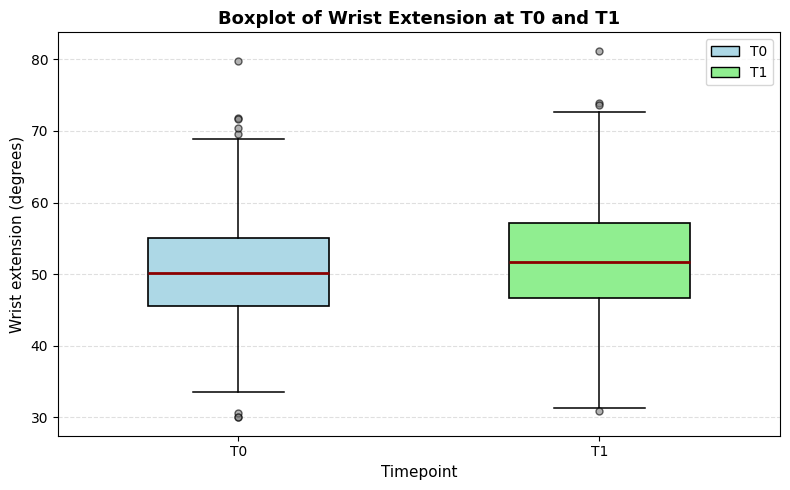

In [20]:
# Boxplot for wrist extension at T0 and T1
fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    [
        analysis_df["wrist_extension_deg_T0"].dropna(),
        analysis_df["wrist_extension_deg_T1"].dropna()
    ],
    tick_labels=["T0", "T1"],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="darkred", linewidth=2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.1),
    capprops=dict(color="black", linewidth=1.1),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markeredgecolor="black",
        alpha=0.6,
        markersize=5
    )
)

# Customize box colors
box["boxes"][0].set_facecolor("lightblue")
box["boxes"][1].set_facecolor("lightgreen")

# Title and labels
ax.set_title("Boxplot of Wrist Extension at T0 and T1", fontsize=13, fontweight="bold")
ax.set_ylabel("Wrist extension (degrees)", fontsize=11)
ax.set_xlabel("Timepoint", fontsize=11)

# Add a light grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add a legend
legend_elements = [
    Patch(facecolor="lightblue", edgecolor="black", label="T0"),
    Patch(facecolor="lightgreen", edgecolor="black", label="T1")
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("results/figures_exploratory/boxplot_wrist_extension_T0_T1.png", dpi=300, bbox_inches="tight")
plt.show()

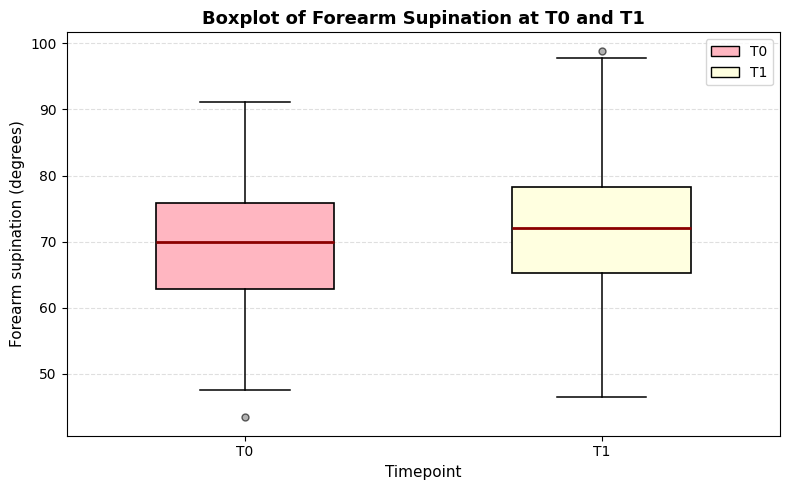

In [21]:
# Boxplot for forearm supination at T0 and T1
fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    [
        analysis_df["forearm_supination_deg_T0"].dropna(),
        analysis_df["forearm_supination_deg_T1"].dropna()
    ],
    tick_labels=["T0", "T1"],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="darkred", linewidth=2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.1),
    capprops=dict(color="black", linewidth=1.1),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markeredgecolor="black",
        alpha=0.6,
        markersize=5
    )
)

# Customize box colors
box["boxes"][0].set_facecolor("lightpink")
box["boxes"][1].set_facecolor("lightyellow")

# Title and labels
ax.set_title("Boxplot of Forearm Supination at T0 and T1", fontsize=13, fontweight="bold")
ax.set_ylabel("Forearm supination (degrees)", fontsize=11)
ax.set_xlabel("Timepoint", fontsize=11)

# Add a light grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add a legend
legend_elements = [
    Patch(facecolor="lightpink", edgecolor="black", label="T0"),
    Patch(facecolor="lightyellow", edgecolor="black", label="T1")
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("results/figures_exploratory/boxplot_forearm_supination_T0_T1.png", dpi=300, bbox_inches="tight")
plt.show()

The boxplots provide a visual comparison of the raw measurements at T0 and T1 for wrist extension and forearm supination.

For wrist extension, the median appears slightly higher at T1 than at T0. The interquartile ranges remain broadly comparable across the two timepoints, suggesting a relatively similar overall spread of the values, although a few extreme observations are visible at both T0 and T1.

For forearm supination, the median also appears slightly higher at T1 than at T0. The distribution at T1 seems somewhat shifted upward, while the overall variability remains of a similar order of magnitude across the two timepoints. A small number of more extreme observations are also visible.

At this stage, these figures are used for descriptive and exploratory purposes only.
They provide a visual overview of the raw measurements before the formal statistical analyses.

#### III.2.2. Histograms of the change scores

Histograms are used to visualize the distribution of the delta variables.

These figures help:
- describe the distribution of the individual changes between T0 and T1,
- identify whether the changes are mostly positive or negative,
- visually inspect the spread of the change scores,
- detect potentially unusual observations.

For each histogram, a vertical line is added for the mean and the median.
A vertical reference line at 0 is also included, because it separates negative changes from positive changes.

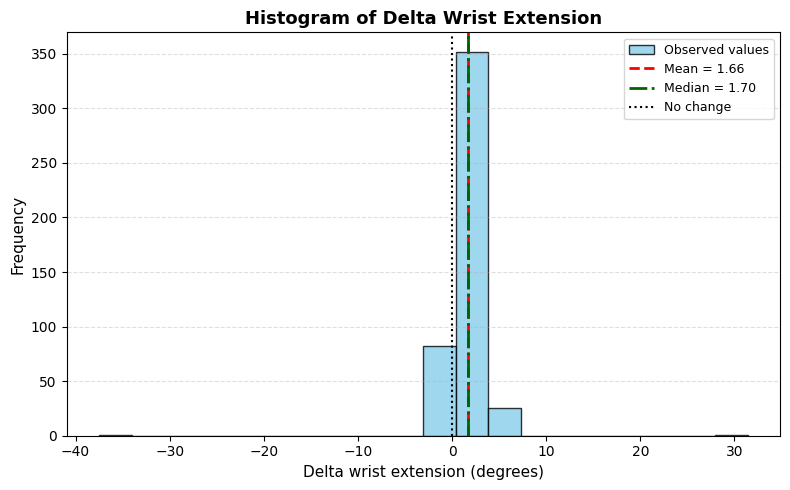

In [22]:
# Histogram for delta wrist extension
data = analysis_df["delta_wrist_extension_deg"].dropna()
mean_value = data.mean()
median_value = data.median()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    data,
    bins=20,
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
    label="Observed values"
)

ax.axvline(mean_value, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_value:.2f}")
ax.axvline(median_value, color="darkgreen", linestyle="-.", linewidth=2, label=f"Median = {median_value:.2f}")
ax.axvline(0, color="black", linestyle=":", linewidth=1.5, label="No change")

ax.set_title("Histogram of Delta Wrist Extension", fontsize=13, fontweight="bold")
ax.set_xlabel("Delta wrist extension (degrees)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right", frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("results/figures_exploratory/histogram_delta_wrist_extension.png", dpi=300, bbox_inches="tight")
plt.show()

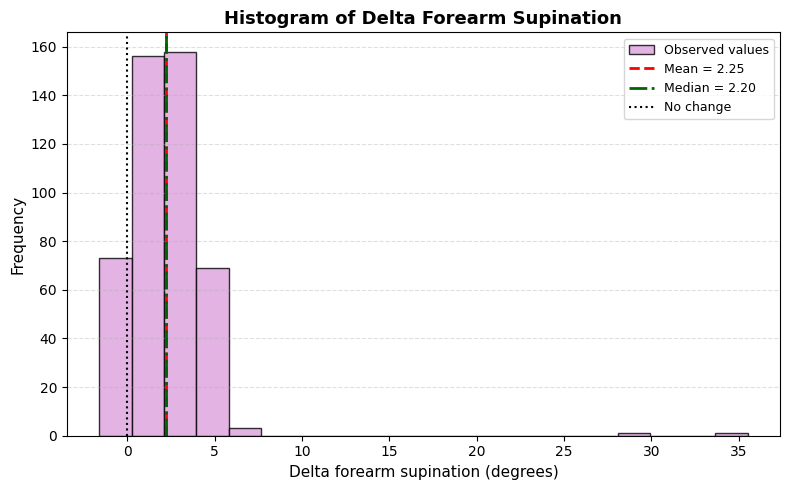

In [23]:
# Histogram for delta forearm supination
data = analysis_df["delta_forearm_supination_deg"].dropna()
mean_value = data.mean()
median_value = data.median()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    data,
    bins=20,
    color="plum",
    edgecolor="black",
    alpha=0.8,
    label="Observed values"
)

ax.axvline(mean_value, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_value:.2f}")
ax.axvline(median_value, color="darkgreen", linestyle="-.", linewidth=2, label=f"Median = {median_value:.2f}")
ax.axvline(0, color="black", linestyle=":", linewidth=1.5, label="No change")

ax.set_title("Histogram of Delta Forearm Supination", fontsize=13, fontweight="bold")
ax.set_xlabel("Delta forearm supination (degrees)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right", frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("results/figures_exploratory/histogram_delta_forearm_supination.png", dpi=300, bbox_inches="tight")
plt.show()

The histograms provide a visual overview of the distribution of the individual change scores between T0 and T1 for wrist extension and forearm supination.

For wrist extension, most delta values appear concentrated around small positive changes. The mean and median are both above 0 and remain very close to each other, suggesting that the distribution is centered on a modest positive change for most participants. A small number of more extreme observations are also visible, including one marked negative value and one marked positive value.

For forearm supination, most delta values also appear concentrated around positive changes. The mean and median are again above 0 and close to each other, indicating that the distribution is centered on a modest positive shift overall. The histogram also shows a few more extreme positive observations, which contribute to a slight right-sided extension of the distribution.

At this stage, these figures are used for descriptive and exploratory purposes only.
They help visualize the overall distribution of the change scores and identify unusual observations before the formal statistical analyses.

## IV. Export the final analysis dataset

In [24]:
#Check our dataset before the export
print(analysis_df.shape)
print(analysis_df.columns.tolist())
print(analysis_df.head())

(461, 7)
['participant_id', 'wrist_extension_deg_T0', 'wrist_extension_deg_T1', 'forearm_supination_deg_T0', 'forearm_supination_deg_T1', 'delta_wrist_extension_deg', 'delta_forearm_supination_deg']
  participant_id  wrist_extension_deg_T0  wrist_extension_deg_T1  \
0           M001                    51.9                    55.3   
1           M002                    43.2                    44.7   
2           M003                    47.2                    47.8   
3           M004                    46.0                    45.1   
4           M005                    56.4                    59.1   

   forearm_supination_deg_T0  forearm_supination_deg_T1  \
0                       82.1                       85.4   
1                       70.5                       74.2   
2                       62.6                       64.3   
3                       72.9                       74.4   
4                       65.2                       69.1   

   delta_wrist_extension_deg  delta_f

At this stage, the final analysis dataset has been fully prepared.

It contains:
- one row per participant,
- complete paired values at T0 and T1 for both movement outcomes,
- the two derived change variables (`delta_wrist_extension_deg` and `delta_forearm_supination_deg`).

The descriptive table, boxplots, and histograms have provided a numerical and visual overview of the dataset and have served as a final exploratory check of the cleaned data.

The dataset is now ready to be exported and used as the reference file for the next steps of the project, including the statistical analyses and additional figures to be produced in RStudio.

In [25]:
import os

# Create the output folder if it does not already exist
os.makedirs("data/processed", exist_ok=True)

# Export the final analysis dataset
analysis_df.to_csv("data/processed/analysis_dataset.csv", index=False)

print("The final analysis dataset was successfully exported to:")
print("data/processed/analysis_dataset.csv")

The final analysis dataset was successfully exported to:
data/processed/analysis_dataset.csv
